# Model Training Pipeline

This notebook covers the model training phase for the Cordis Sentinel project. We will:

1. Load the engineered features
2. Split the data into train and test sets
3. Apply SMOTE to the training set to handle class imbalance
4. Train baseline models: **Logistic Regression** and **Decision Tree Classifier**
5. Evaluate models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC
6. Save the best model for the downstream explainability and agentic layers

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load Engineered Data

In [11]:
df = pd.read_csv('../data/processed/features_engineered.csv')

print(f"Shape: {df.shape}")
TARGET = 'heart_attack_risk'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Shape: (7000, 32)
Feature matrix shape: (7000, 31)
Target shape: (7000,)


## 2. Train-Test Split

We use an 80/20 stratified split to maintain the target class distribution in both sets.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"\nTrain class distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Train size : 5600 samples
Test size  : 1400 samples

Train class distribution:
heart_attack_risk
0    0.58
1    0.42
Name: proportion, dtype: float64

Test class distribution:
heart_attack_risk
0    0.58
1    0.42
Name: proportion, dtype: float64


## 3. Handle Class Imbalance with SMOTE

We apply **SMOTE** (Synthetic Minority Over-sampling Technique) **only to the training split** to avoid data leakage.

In [13]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Train size after SMOTE : {X_train_res.shape[0]} samples")
print(f"\nClass distribution after SMOTE:")
unique, counts = np.unique(y_train_res, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples")

Train size after SMOTE : 6496 samples

Class distribution after SMOTE:
  Class 0: 3248 samples
  Class 1: 3248 samples


## 4. Train Models

We'll train a Logistic Regression model as a strong linear baseline, and a Decision Tree Classifier as a non-linear baseline. Both are inherently interpretable, aligning with our project goals.

In [14]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5) # constrain depth to prevent overfitting
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model

print("\nTraining complete.")

Training Logistic Regression...
Training Decision Tree...

Training complete.


## 5. Evaluate Models

We'll evaluate the models on the untouched test set.

In [15]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    print(f"--- {model_name} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}\n")
    
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC': roc_auc}, y_pred, y_prob

results = {}
predictions = {}

for name, model in trained_models.items():
    metrics, y_pred, y_prob = evaluate_model(model, X_test, y_test, name)
    results[name] = metrics
    predictions[name] = {'pred': y_pred, 'prob': y_prob}

--- Logistic Regression ---
Accuracy  : 0.7764
Precision : 0.7311
Recall    : 0.7398
F1 Score  : 0.7354
ROC AUC   : 0.8608

--- Decision Tree ---
Accuracy  : 0.7071
Precision : 0.6503
Recall    : 0.6548
F1 Score  : 0.6525
ROC AUC   : 0.7604



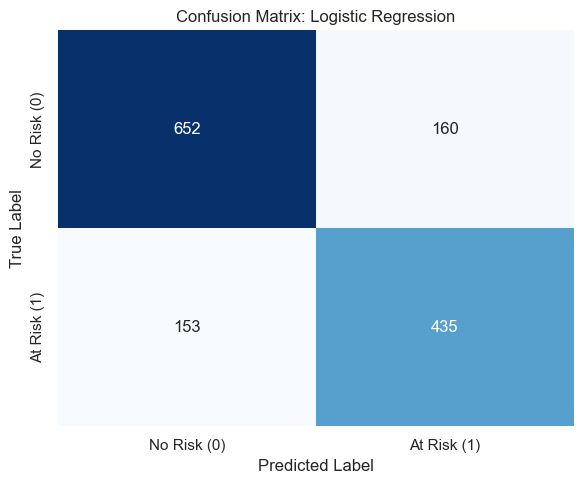

In [16]:
# Plot Confusion Matrix for Logistic Regression
name = "Logistic Regression"
cm = confusion_matrix(y_test, predictions[name]['pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['No Risk (0)', 'At Risk (1)'])
plt.yticks([0.5, 1.5], ['No Risk (0)', 'At Risk (1)'])
plt.tight_layout()
plt.show()

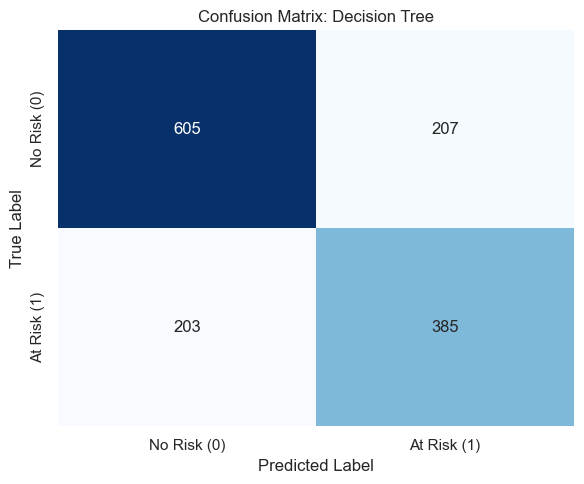

In [17]:
# Plot Confusion Matrix for Decision Tree
name = "Decision Tree"
cm = confusion_matrix(y_test, predictions[name]['pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['No Risk (0)', 'At Risk (1)'])
plt.yticks([0.5, 1.5], ['No Risk (0)', 'At Risk (1)'])
plt.tight_layout()
plt.show()

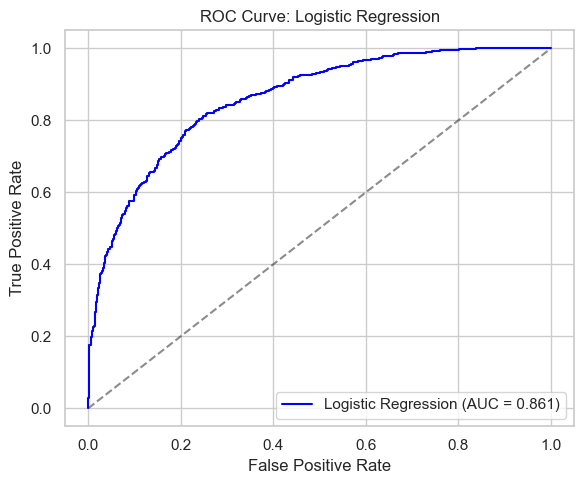

In [18]:
# Plot ROC Curve for Logistic Regression
name = "Logistic Regression"
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, predictions[name]['prob'])
auc_score = results[name]['ROC_AUC']
plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve: {name}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

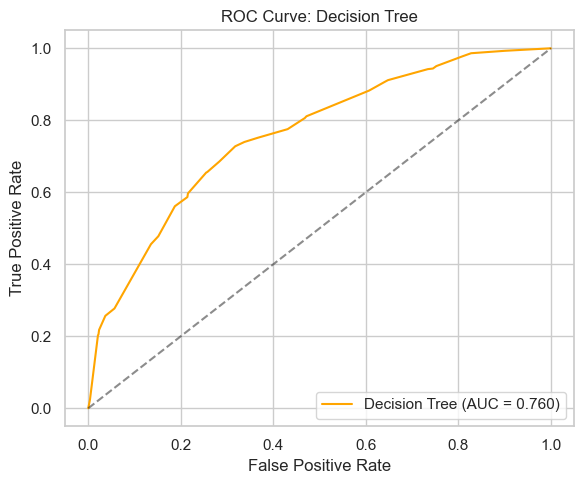

In [19]:
# Plot ROC Curve for Decision Tree
name = "Decision Tree"
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, predictions[name]['prob'])
auc_score = results[name]['ROC_AUC']
plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve: {name}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Save Best Model

Based on the evaluation metrics (especially ROC-AUC and Recall, which is critical for risk prediction), Logistic Regression typically provides a robust baseline with smooth SHAP values for explainability.

In [20]:
# We select Logistic Regression as our primary model for the agentic pipeline
best_model_name = "Logistic Regression"
best_model = trained_models[best_model_name]

os.makedirs('../models', exist_ok=True)
model_path = '../models/logistic_regression_model.pkl'
joblib.dump(best_model, model_path)

print(f"Selected Best Model: {best_model_name}")
print(f"Model saved to {model_path}")

Selected Best Model: Logistic Regression
Model saved to ../models/logistic_regression_model.pkl


## 7. Summary

| Step | Action | Detail |
|---|---|---|
| Data Loading | Loaded `features_engineered.csv` | Full dataset with OHE and scaling |
| Data Splitting | 80/20 Train-Test split | Stratified to maintain class balance |
| Oversampling | Applied SMOTE | Only on the training set to prevent leakage |
| Model Training | Logistic Regression & Decision Tree | Trained on SMOTE-balanced training data |
| Model Eval | Accuracy, Precision, Recall, F1, ROC-AUC | Evaluated on untouched test data |
| Model Saving | Saved Logistic Regression | Persisted as `logistic_regression_model.pkl` |

➡️ **Next step:** `06_model_evaluation_shap.ipynb` — Generate SHAP values to explain the model's predictions and prepare the inputs for the agentic reasoning layer.